# Verificación de normalidad y cálculo de probabilidades

Este notebook usa un conjunto de datos de **tiempos de entrega de paquetes (en minutos)** para:

1. cargar los datos,
2. calcular estadísticas descriptivas,
3. visualizar histograma y curva normal ajustada,
4. verificar si los datos se comportan aproximadamente como una normal,
5. calcular probabilidades y percentiles,
6. interpretar los resultados.

Puedes ejecutar cada celda en orden.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos: tiempos de entrega (minutos)
data = np.array([0, 1, 2, 3, 2, 1, 0, 2, 3, 4, 2, 1, 2, 3, 2])

n = len(data)
print("Número de observaciones:", n)
print("Datos:", data)


Número de observaciones: 15
Datos: [0 1 2 3 2 1 0 2 3 4 2 1 2 3 2]


## 1. Media, desviación estándar y resumen básico

Calculamos la media muestral, la desviación estándar muestral y algunos valores resumen.


In [2]:
media = np.mean(data)
desv = np.std(data, ddof=1)   # ddof=1 para desviación estándar muestral
varianza = np.var(data, ddof=1)

print(f"Media muestral = {media:.4f}")
print(f"Desviación estándar muestral = {desv:.4f}")
print(f"Varianza muestral = {varianza:.4f}")
print(f"Mínimo = {np.min(data)}")
print(f"Máximo = {np.max(data)}")
print(f"Mediana = {np.median(data):.4f}")


Media muestral = 1.8667
Desviación estándar muestral = 1.1255
Varianza muestral = 1.2667
Mínimo = 0
Máximo = 4
Mediana = 2.0000


## 2. Histograma de los datos

Observamos la forma general de la distribución. Si el histograma es aproximadamente simétrico y con forma de campana, eso apoya el comportamiento normal.


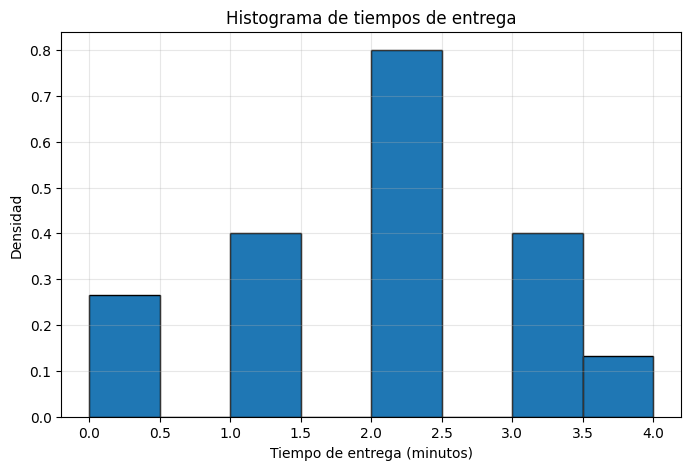

In [3]:
plt.figure(figsize=(8,5))
plt.hist(data, bins=8, edgecolor='black', density=True)
plt.xlabel("Tiempo de entrega (minutos)")
plt.ylabel("Densidad")
plt.title("Histograma de tiempos de entrega")
plt.grid(alpha=0.3)
plt.show()


## 3. Histograma con curva normal ajustada

Ajustamos una normal usando la media y desviación estándar muestral:

\
X \sim N(\mu,\sigma^2)
\

donde \(\mu\) y \(\sigma\) se estiman con los datos.


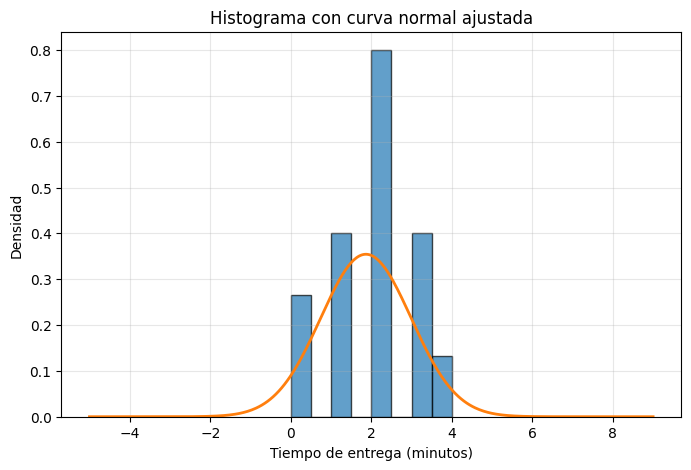

In [4]:
x = np.linspace(min(data)-5, max(data)+5, 400)
y = stats.norm.pdf(x, loc=media, scale=desv)

plt.figure(figsize=(8,5))
plt.hist(data, bins=8, edgecolor='black', density=True, alpha=0.7)
plt.plot(x, y, linewidth=2)
plt.xlabel("Tiempo de entrega (minutos)")
plt.ylabel("Densidad")
plt.title("Histograma con curva normal ajustada")
plt.grid(alpha=0.3)
plt.show()


## 4. Gráfico Q-Q

El gráfico Q-Q compara los cuantiles observados con los cuantiles teóricos de una normal.

- Si los puntos quedan cerca de una línea recta, el ajuste normal es razonable.
- Si se alejan mucho, la normalidad puede no ser buena.


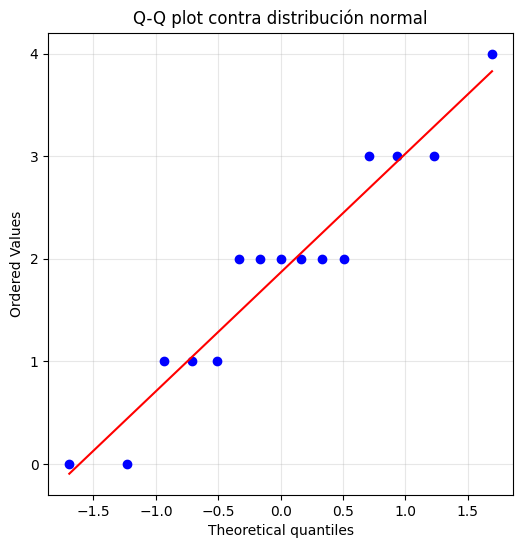

In [5]:
plt.figure(figsize=(6,6))
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q plot contra distribución normal")
plt.grid(alpha=0.3)
plt.show()


## 5. Prueba de normalidad

Usaremos la prueba de **Shapiro-Wilk**.

- **Hipótesis nula**: los datos provienen de una distribución normal.
- **Hipótesis alternativa**: los datos no provienen de una distribución normal.

Criterio típico:
- si el valor-p > 0.05, no se rechaza la normalidad;
- si el valor-p \(\leq\) 0.05, se rechaza la normalidad.


In [6]:
stat, pvalor = stats.shapiro(data)

print(f"Estadístico de Shapiro-Wilk = {stat:.4f}")
print(f"Valor-p = {pvalor:.4f}")

if pvalor > 0.05:
    print("Conclusión: no se rechaza la hipótesis de normalidad.")
else:
    print("Conclusión: se rechaza la hipótesis de normalidad.")


Estadístico de Shapiro-Wilk = 0.9304
Valor-p = 0.2762
Conclusión: no se rechaza la hipótesis de normalidad.


## 6. Cálculo de probabilidades con la normal ajustada

Supondremos que los tiempos de entrega se comportan aproximadamente como

\[
X \sim N(\mu,\sigma^2)
\]

con \(\mu =\) media muestral y \(\sigma =\) desviación estándar muestral.

Calcularemos:

1. \(P(X<50)\)
2. \(P(X>70)\)
3. \(P(55<X<65)\)


In [7]:
p_menos_50 = stats.norm.cdf(50, loc=media, scale=desv)
p_mas_70 = 1 - stats.norm.cdf(70, loc=media, scale=desv)
p_entre_55_65 = stats.norm.cdf(65, loc=media, scale=desv) - stats.norm.cdf(55, loc=media, scale=desv)

print(f"P(X < 50) = {p_menos_50:.4f}")
print(f"P(X > 70) = {p_mas_70:.4f}")
print(f"P(55 < X < 65) = {p_entre_55_65:.4f}")


P(X < 50) = 1.0000
P(X > 70) = 0.0000
P(55 < X < 65) = 0.0000


## 7. Percentil 90

Buscamos el tiempo \(t\) tal que el 90% de las entregas ocurra antes de ese valor:

\[
P(X \le t)=0.90
\]

Esto se obtiene con la función cuantil o inversa de la normal.


In [8]:
percentil_90 = stats.norm.ppf(0.90, loc=media, scale=desv)
print(f"Percentil 90 = {percentil_90:.4f} minutos")


Percentil 90 = 3.3090 minutos


## 8. Visualización de probabilidades

Mostramos en una gráfica:
- la media,
- la región \(X<50\),
- la región \(X>70\),
- la región \(55<X<65\).


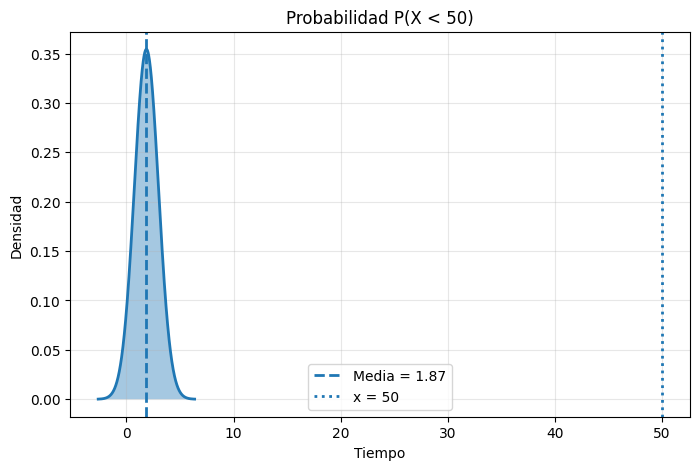

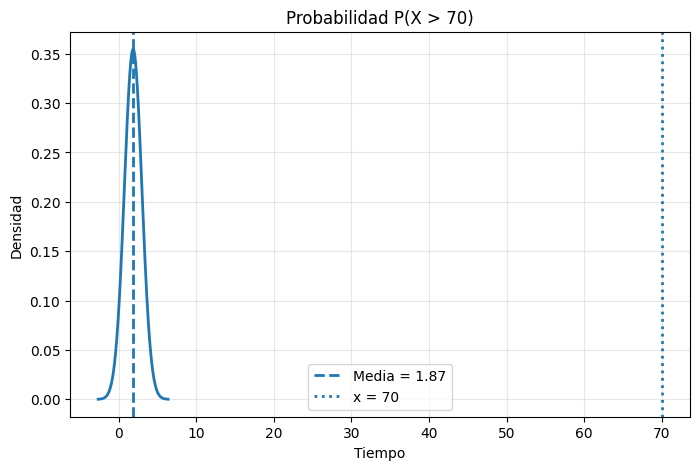

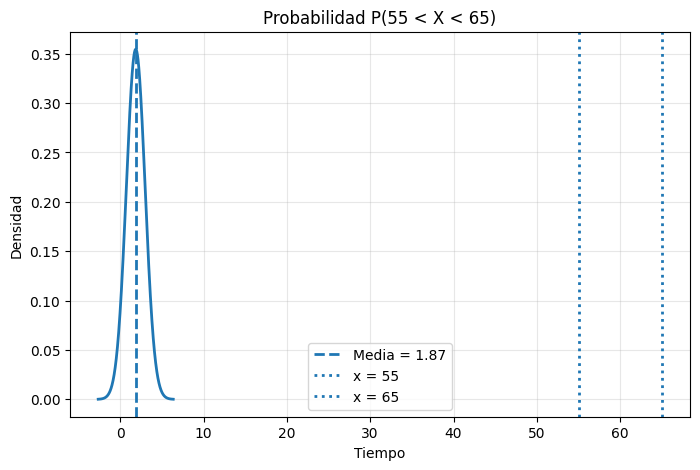

In [9]:
x = np.linspace(media - 4*desv, media + 4*desv, 500)
y = stats.norm.pdf(x, loc=media, scale=desv)

# Gráfica para P(X<50)
plt.figure(figsize=(8,5))
plt.plot(x, y, linewidth=2)
plt.fill_between(x, y, where=(x < 50), alpha=0.4)
plt.axvline(media, linestyle='--', linewidth=2, label=f"Media = {media:.2f}")
plt.axvline(50, linestyle=':', linewidth=2, label="x = 50")
plt.title("Probabilidad P(X < 50)")
plt.xlabel("Tiempo")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfica para P(X>70)
plt.figure(figsize=(8,5))
plt.plot(x, y, linewidth=2)
plt.fill_between(x, y, where=(x > 70), alpha=0.4)
plt.axvline(media, linestyle='--', linewidth=2, label=f"Media = {media:.2f}")
plt.axvline(70, linestyle=':', linewidth=2, label="x = 70")
plt.title("Probabilidad P(X > 70)")
plt.xlabel("Tiempo")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Gráfica para P(55<X<65)
plt.figure(figsize=(8,5))
plt.plot(x, y, linewidth=2)
plt.fill_between(x, y, where=((x > 55) & (x < 65)), alpha=0.4)
plt.axvline(media, linestyle='--', linewidth=2, label=f"Media = {media:.2f}")
plt.axvline(55, linestyle=':', linewidth=2, label="x = 55")
plt.axvline(65, linestyle=':', linewidth=2, label="x = 65")
plt.title("Probabilidad P(55 < X < 65)")
plt.xlabel("Tiempo")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Interpretación final

Completa esta parte después de ejecutar el notebook:

- ¿El histograma parece aproximadamente simétrico?
- ¿El Q-Q plot se acerca a una línea recta?
- ¿La prueba de Shapiro-Wilk rechaza o no la normalidad?
- ¿Qué significan las probabilidades calculadas en el contexto de los tiempos de entrega?
- ¿Qué indica el percentil 90 sobre el rendimiento del sistema?

### Posible conclusión
Si el histograma, el Q-Q plot y la prueba de normalidad muestran buen ajuste, entonces es razonable modelar los tiempos de entrega con una distribución normal y usar esa aproximación para estimar probabilidades y percentiles.


## 10. Ejercicio para el estudiante

Con base en el análisis anterior, responda:

1. ¿Los datos se comportan aproximadamente como una normal? Justifique con histograma, Q-Q plot y prueba de Shapiro-Wilk.
2. Calcule la probabilidad de que un paquete tarde menos de 50 minutos.
3. Calcule la probabilidad de que un paquete tarde más de 70 minutos.
4. Calcule la probabilidad de que un paquete tarde entre 55 y 65 minutos.
5. Halle el tiempo por debajo del cual cae el 90% de las entregas.
6. Interprete sus resultados en el contexto de la empresa de logística.
